In [1]:
%pip install pytorch_lightning -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install pandas -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib seaborn pytorch_lightning scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


# Распаковка датасетика

In [5]:
import pandas as pd
import re
import torch
import zipfile
from collections import Counter
import os

import pytorch_lightning as pl

pl.seed_everything(322, workers=True)

Seed set to 322


322

In [6]:
zip_filename = 'tripadvisor_hotel_reviews.csv.zip'
csv_filename = 'tripadvisor_hotel_reviews.csv'

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv(csv_filename)
print(f"Размер {df.shape}")

Размер (20491, 2)


# Посмотрим на данные

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [8]:
display(df.head())

df.info()

print(f"\nКол-во дублей {df.duplicated().sum()}")

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB

Кол-во дублей 0


посмотрим какие классы и как выглядит распределение

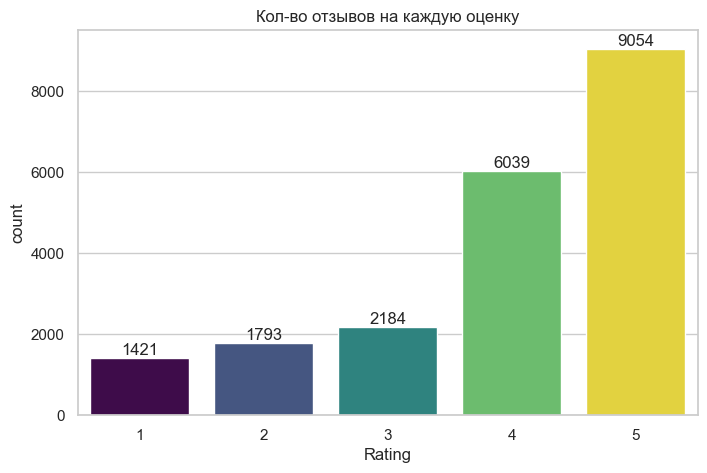

Rating
1    0.069348
2    0.087502
3    0.106583
4    0.294715
5    0.441853
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Rating', data=df, palette='viridis', hue='Rating', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
                
plt.title('Кол-во отзывов на каждую оценку')
plt.show()

print(df['Rating'].value_counts(normalize=True).sort_index())

Печально :с

Дисбалансик есть

слишкио мало 1-3 оценок
и очень много 5

Надо что-то типа stratify, иначе модель будет всем ставить оценку "5"

Посмотрим сколько слов в среднем, какое распределение по словам в отзывах

count    20491.000000
mean       104.375824
std        100.656586
min          7.000000
25%         48.000000
50%         77.000000
75%        124.000000
max       1931.000000
Name: word_count, dtype: float64


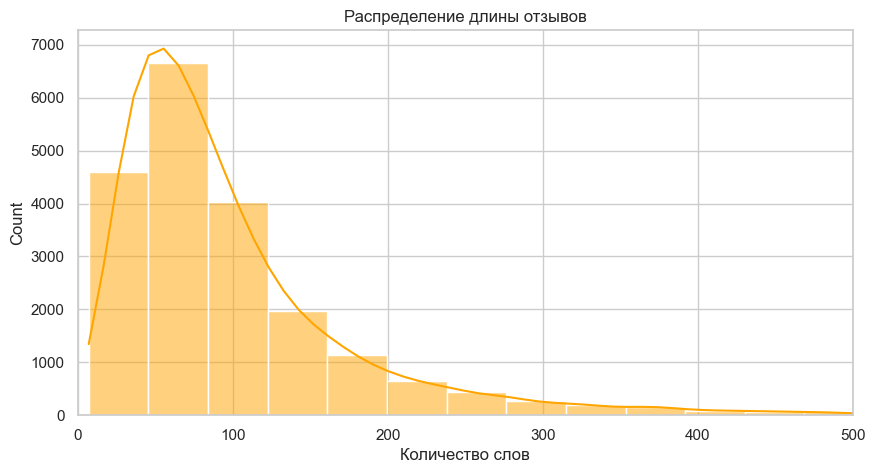

In [10]:
df['word_count'] = df['Review'].astype(str).apply(lambda x: len(x.split()))

print(df['word_count'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='orange')
plt.title('Распределение длины отзывов')
plt.xlabel('Количество слов')
plt.xlim(0, 500)
plt.show()

посмотрим какая длина отзыва у 95й перцентиля отзывов

In [11]:
p95 = df['word_count'].quantile(0.95)
print(p95)

275.0


Нормально, знаем теперь как комфортно можно ограничить максимальную длину отзывы для дальнейшей токенизации

# Предобработаем данные

In [12]:
import re
import numpy as np
import torch
from collections import Counter

Сделаем базу по типу приведем все к единому регистру (просто сделаем нижний), уберем цифры и вообще все то, что не относится к буквам (шумно по идее из-за них), уберем пробелы

Это поможет нам убрать шум, снизить кол-во потребляемой памяти

In [13]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'[^a-z\s]', '', text)

    text = ' '.join(text.split())

    return text

Вот тут еще мы сдвинем классы к 0-4 вместо 1-5, так как я хочу использовать `CrossEntropyLoss`, а он любит только если с 0 начинается

In [14]:
df['Review_Clean'] = df['Review'].astype(str).apply(clean_text)

df['Target'] = df['Rating'] - 1

И еще сделаем такую штуку, как подсчет весов для каждого класса. Так как у нас жесткий дисбаланс, надо как-то урегулировать это. Можно посчитать на основе частоты этого класса. Тем меньше, тем больше вес.

In [15]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

all_targets = df['Target'].values 

class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(all_targets), 
    y=all_targets
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Веса", class_weights_tensor)

Веса tensor([2.8840, 2.2857, 1.8765, 0.6786, 0.4526])


Сравним как было до очистки и после

In [16]:
sample_idx = 50

print(f"До\n{df['Review'].iloc[sample_idx][:200]}...")

print(f"После\n{df['Review_Clean'].iloc[sample_idx][:200]}...")

До
excellent way stayed inn market memorial day weekend, room large great view water sure request way advance, hotel quiet fully booked crowded, service impeccable staff well-mannered friendly, ca n't fa...
После
excellent way stayed inn market memorial day weekend room large great view water sure request way advance hotel quiet fully booked crowded service impeccable staff wellmannered friendly ca nt fault an...


Красивое

Теперь токенизируем всё

In [17]:
MAX_VOCAB_SIZE = 10000
MAX_LEN = 300

all_words = ' '.join(df['Review_Clean']).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(MAX_VOCAB_SIZE - 2)

vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in common_words:
    vocab[word] = len(vocab)

Так как у нас не все отзывы 275 длиной ровно, остальное пространство забьем паддингом в виде 0

In [18]:
def text_to_sequence(text, vocab, max_len):
    indices = [vocab.get(word, vocab['<UNK>']) for word in text.split()]

    if len(indices) < max_len:
        indices += [vocab['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

X_indices = [text_to_sequence(text, vocab, MAX_LEN) for text in df['Review_Clean']]

X_tensor = torch.tensor(X_indices, dtype=torch.long)
y_tensor = torch.tensor(df['Target'].values, dtype=torch.long)

In [19]:
print(f"Словарь {len(vocab)}")
print(f"X {X_tensor.shape}")
print(f"y {y_tensor.shape}")

Словарь 10000
X torch.Size([20491, 300])
y torch.Size([20491])


Ради интереса посмотрим как выглядит токенизированный текст

In [20]:
idx_to_word = {index: word for word, index in vocab.items()}

example_idx = 52

raw_text = df['Review_Clean'].iloc[example_idx]
token_vector = X_indices[example_idx]

print(f"Отзыв №{example_idx} ===")
print(f"Длина текста {len(raw_text.split())} слова")
print(f"Текст\n{raw_text[:100]}...")
print("Токены")
print(token_vector[:20])

Отзыв №52 ===
Длина текста 64 слова
Текст
outstanding choice reserved city view room night week checkin helpful desk staff amy gave compliment...
Токены
[608, 212, 1035, 63, 50, 3, 19, 102, 334, 39, 53, 8, 1, 244, 427, 473, 91, 51, 45, 50]


Забавное

## Разбиение датасетика

In [21]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

Ну у нас есть условие лабы, где 60/20/20, поэтому так и сделаем. Ну и тут сразу прописал батч равный 64. Базовый достаточно, не знаю как аргументировать

In [22]:
class DataModule(pl.LightningDataModule):
    def __init__(self, X_tensor, y_tensor, batch_size=64):
        super().__init__()
        self.X = X_tensor
        self.y = y_tensor
        self.batch_size = batch_size

    def setup(self, stage=None):
        X_train, X_temp, y_train, y_temp = train_test_split(
            self.X, self.y,
            test_size=0.4,
            stratify=self.y,
            random_state=322
        )

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=0.5,
            stratify=y_temp,
            random_state=322
        )

        self.train_ds = TensorDataset(X_train, y_train)
        self.val_ds = TensorDataset(X_val, y_val)
        self.test_ds = TensorDataset(X_test, y_test)

        print(f"Train {len(X_train)}")
        print(f"Val  {len(X_val)}")
        print(f"Test  {len(X_test)}")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=4, persistent_workers=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, num_workers=4, persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, num_workers=4, persistent_workers=True)

dm = DataModule(X_tensor, y_tensor, batch_size=64)

## Единый класс для всего процесса обучения

Здесь ничего необычного. Взял православный AdamW. Функция потерь - `nn.CrossEntropyLoss()`. Метрика основная F1 weighted, так как она лучше учиытывает дисбаланс классов. И еще F1 macro чтобы посмотреть на среднее по каждому классу

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from sklearn.metrics import f1_score, classification_report

In [24]:
class PipelineStart(pl.LightningModule):
    def __init__(self, model, learning_rate=1e-3, class_weights=None):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        
        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.criterion = nn.CrossEntropyLoss()

        self.history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        avg_loss = self.trainer.callback_metrics.get('train_loss')
        if avg_loss is not None:
            self.history['train_loss'].append(avg_loss.item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)

        self.validation_step_outputs.append({'preds': preds, 'targets': y, 'loss': loss})
        return loss

    def on_validation_epoch_end(self):
        outputs = self.validation_step_outputs

        all_preds = torch.cat([x['preds'] for x in outputs]).cpu().numpy()
        all_targets = torch.cat([x['targets'] for x in outputs]).cpu().numpy()
        avg_loss = torch.stack([x['loss'] for x in outputs]).mean()

        f1_weighted = f1_score(all_targets, all_preds, average='weighted')
        f1_macro = f1_score(all_targets, all_preds, average='macro')

        self.log('val_loss', avg_loss, prog_bar=True)
        self.log('val_f1', f1_weighted, prog_bar=True)
        self.log('val_f1_macro', f1_macro, prog_bar=True)

        self.history['val_loss'].append(avg_loss.item())
        self.history['val_f1'].append(f1_weighted)

        self.validation_step_outputs.clear()

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        self.test_step_outputs.append({'preds': preds, 'targets': y})

    def on_test_epoch_end(self):
        outputs = self.test_step_outputs
        all_preds = torch.cat([x['preds'] for x in outputs]).cpu().numpy()
        all_targets = torch.cat([x['targets'] for x in outputs]).cpu().numpy()

        print(classification_report(all_targets, all_preds, target_names=['1 star', '2 stars', '3 stars', '4 stars', '5 stars']))

        f1 = f1_score(all_targets, all_preds, average='weighted')
        self.log('test_f1', f1)
        self.test_step_outputs.clear()

    def configure_optimizers(self):
        return optim.AdamW(self.model.parameters(), lr=self.learning_rate, weight_decay=0.01)

# Обучение

In [25]:
V_SIZE = len(vocab)

## CNN

Тут ничего особенного, стандартная свертка

In [26]:
class CNN_Net(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv = nn.Conv1d(in_channels=embed_dim, out_channels=64, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)

        x = x.permute(0, 2, 1)

        x = self.conv(x)
        x = self.relu(x)

        x = self.pool(x).squeeze(2)
        return self.fc(x)

In [27]:
cnn_system = PipelineStart(CNN_Net(V_SIZE), learning_rate=1e-3, class_weights=class_weights_tensor)

In [28]:
early_stop_cnn = pl.callbacks.EarlyStopping(
    monitor='val_f1', patience=5, mode='max', verbose=True
)

trainer_cnn = pl.Trainer(
    max_epochs=10,
    accelerator='mps',
    devices=1,
    callbacks=[early_stop_cnn],
    enable_progress_bar=True
)

trainer_cnn.fit(cnn_system, dm)

trainer_cnn.test(cnn_system, dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | CNN_Net          | 1.3 M  | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.220     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Train 12294
Val  4098
Test  4099
Epoch 0: 100%|██████████| 193/193 [00:03<00:00, 60.19it/s, v_num=10, val_loss=1.270, val_f1=0.447, val_f1_macro=0.397, train_loss=1.430]

Metric val_f1 improved. New best score: 0.447


Epoch 1: 100%|██████████| 193/193 [00:01<00:00, 175.71it/s, v_num=10, val_loss=1.180, val_f1=0.528, val_f1_macro=0.442, train_loss=1.120]

Metric val_f1 improved by 0.081 >= min_delta = 0.0. New best score: 0.528


...

Metric val_f1 improved by 0.032 >= min_delta = 0.0. New best score: 0.560


Epoch 8: 100%|██████████| 193/193 [00:01<00:00, 182.33it/s, v_num=10, val_loss=1.340, val_f1=0.553, val_f1_macro=0.482, train_loss=0.232]

Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.560. Signaling Trainer to stop.


Epoch 8: 100%|██████████| 193/193 [00:01<00:00, 179.29it/s, v_num=10, val_loss=1.340, val_f1=0.553, val_f1_macro=0.482, train_loss=0.232]
Train 12294
Val  4098
Test  4099
Testing DataLoader 0: 100%|██████████| 65/65 [00:00<00:00, 409.24it/s]              precision    recall  f1-score   support

      1 star       0.59      0.55      0.57       284
     2 stars       0.36      0.43      0.39       359
     3 stars       0.35      0.24      0.29       437
     4 stars       0.47      0.47      0.47      1208
     5 stars       0.69      0.73      0.71      1811

    accuracy                           0.56      4099
   macro avg       0.49      0.48      0.49      4099
weighted avg       0.56      0.56      0.56      4099

Testing DataLoader 0: 100%|██████████| 65/65 [00:00<00:00, 384.32it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
──────────────────────────────────

[{'test_f1': 0.5575796365737915}]

## LSTM

Тут тоже ничего особенного, это однонаправленный LSTM. Только мы берем не последнее состояние `h_n[-1]`, а среднее по словам. Чтобы базовая LSTM не умерла от длинных отзывов.

In [29]:
class LSTM_Net(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)

        output, _ = self.lstm(x) 
        
        x = torch.mean(output, dim=1) 
        
        return self.fc(x)

In [30]:
lstm_system = PipelineStart(LSTM_Net(V_SIZE), learning_rate=1e-3, class_weights=class_weights_tensor)

In [31]:
early_stop_lstm = pl.callbacks.EarlyStopping(
    monitor='val_f1', patience=5, mode='max', verbose=True
)

trainer_lstm = pl.Trainer(
    max_epochs=10,
    accelerator='mps',
    devices=1,
    callbacks=[early_stop_lstm],
    enable_progress_bar=True
)

trainer_lstm.fit(lstm_system, dm)

trainer_lstm.test(lstm_system, dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | LSTM_Net         | 1.3 M  | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.320     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Train 12294
Val  4098
Test  4099
Epoch 0: 100%|██████████| 193/193 [00:05<00:00, 35.26it/s, v_num=11, val_loss=1.410, val_f1=0.369, val_f1_macro=0.257, train_loss=1.560]

Metric val_f1 improved. New best score: 0.369


Epoch 1: 100%|██████████| 193/193 [00:03<00:00, 57.14it/s, v_num=11, val_loss=1.350, val_f1=0.471, val_f1_macro=0.394, train_loss=1.290]

Metric val_f1 improved by 0.102 >= min_delta = 0.0. New best score: 0.471


...

Metric val_f1 improved by 0.003 >= min_delta = 0.0. New best score: 0.571


Epoch 9: 100%|██████████| 193/193 [00:03<00:00, 51.58it/s, v_num=11, val_loss=1.320, val_f1=0.571, val_f1_macro=0.525, train_loss=0.624]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 193/193 [00:03<00:00, 51.33it/s, v_num=11, val_loss=1.320, val_f1=0.571, val_f1_macro=0.525, train_loss=0.624]
Train 12294
Val  4098
Test  4099
Testing DataLoader 0: 100%|██████████| 65/65 [00:00<00:00, 122.09it/s]              precision    recall  f1-score   support

      1 star       0.70      0.55      0.61       284
     2 stars       0.40      0.48      0.44       359
     3 stars       0.28      0.49      0.35       437
     4 stars       0.46      0.48      0.47      1208
     5 stars       0.78      0.62      0.69      1811

    accuracy                           0.55      4099
   macro avg       0.52      0.52      0.51      4099
weighted avg       0.59      0.55      0.56      4099

Testing DataLoader 0: 100%|██████████| 65/65 [00:00<00:00, 118.90it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
───────────────────────────────────

[{'test_f1': 0.5613137483596802}]

## Advanced LSTM

Здесь уже добавил 2 направления, то есть слева направо и справа налево, модель будет знать контекст до и после, что ей сильно поможет.

Сделано 2 слоя, чтобы каждый учил свой уровень абстракций, где 1ый это про что-от простое, а 2ой вещи посложнее.

Мой любимый `Dropout`, чтобы учились все нейроны!!! Как в СССР

И конкатенация обоих направлений в одно, чтобы видеть весь контекст

Также здесь расширен скрытый слой до 256

И добавлен линейный слой перед выходом

In [32]:
class Advanced_Net(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=embed_dim, 
            hidden_size=hidden_dim, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True, 
            dropout=0.3
        )
        
        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (h_n, _) = self.lstm(x)
        
        cat_hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        
        x = self.fc1(cat_hidden)
        x = self.relu(x)
        return self.fc2(x)

In [33]:
adv_system = PipelineStart(Advanced_Net(V_SIZE), learning_rate=1e-3, class_weights=class_weights_tensor)

In [34]:
early_stop_adv = pl.callbacks.EarlyStopping(
    monitor='val_f1', patience=5, mode='max', verbose=True
)

trainer_adv = pl.Trainer(
    max_epochs=15,
    accelerator='mps',
    devices=1,
    callbacks=[early_stop_adv],
    enable_progress_bar=True
)

trainer_adv.fit(adv_system, dm)

trainer_adv.test(adv_system, dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | Advanced_Net     | 3.7 M  | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
3.7 M     Trainable params
0         Non-trainable params
3.7 M     Total params
14.855    Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Train 12294
Val  4098
Test  4099
Epoch 0: 100%|██████████| 193/193 [00:35<00:00,  5.49it/s, v_num=12, val_loss=1.260, val_f1=0.438, val_f1_macro=0.409, train_loss=1.310]

Metric val_f1 improved. New best score: 0.438


Epoch 1: 100%|██████████| 193/193 [00:33<00:00,  5.80it/s, v_num=12, val_loss=1.220, val_f1=0.546, val_f1_macro=0.477, train_loss=1.110]

Metric val_f1 improved by 0.108 >= min_delta = 0.0. New best score: 0.546


...

Metric val_f1 improved by 0.008 >= min_delta = 0.0. New best score: 0.592


Epoch 13: 100%|██████████| 193/193 [00:33<00:00,  5.83it/s, v_num=12, val_loss=2.830, val_f1=0.563, val_f1_macro=0.500, train_loss=0.129]

Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.592. Signaling Trainer to stop.


Epoch 13: 100%|██████████| 193/193 [00:33<00:00,  5.82it/s, v_num=12, val_loss=2.830, val_f1=0.563, val_f1_macro=0.500, train_loss=0.129]
Train 12294
Val  4098
Test  4099
Testing DataLoader 0: 100%|██████████| 65/65 [00:03<00:00, 18.00it/s]              precision    recall  f1-score   support

      1 star       0.66      0.54      0.59       284
     2 stars       0.36      0.48      0.41       359
     3 stars       0.36      0.37      0.36       437
     4 stars       0.49      0.55      0.52      1208
     5 stars       0.75      0.66      0.70      1811

    accuracy                           0.57      4099
   macro avg       0.52      0.52      0.52      4099
weighted avg       0.59      0.57      0.58      4099

Testing DataLoader 0: 100%|██████████| 65/65 [00:03<00:00, 17.94it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────

[{'test_f1': 0.5785090327262878}]

# Результаты

Лучше всего на тестовой вборке себя показывает Advanced LSTM, метрика ~0.58. Хотя справедливости ради CNN и Basic LSTM отстали совсем не сильно, так как у них обеих около 0.56.

Можно выделить, что CNN не хватает глубины, так как она уже на 3ой эпохе выучилась и вышла на плато, а обе LSTM еще учились.

Я считаю, что основная проблема это архитектура и дисбаланс классов

Я пытался решить дисбаланс классов путем введения весов для каждого класса. А эти веса рассчитаны на основе частоты этого класса в датасете. На самом деле это помогло, так как я запускал без нее обучение и там классы 1-2 вообще стремятся к 0 по F1.

И да, архитектура важна. CNN не хватает глубины, обычному LSTM становится плохо на длинных отзывах (как раз наш случай, у нас длинные отзывы), но он дал уровень CNN. А улучшенный LSTM конечно лучше по метрикам, но не существенно, хотя по идее я пытался через двунаправленный проход + 2 слоя решить проблему затухания. Но не помогло :c